# CNN Final Project:- Image Classifier, using ResNet50

In [1]:
# Imports
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.applications import resnet50
from tensorflow.keras.applications.resnet import preprocess_input
from helper_functions import *
import os
import random
import shutil
from tensorflow import keras
from tensorflow.keras import layers

* Steps to follow:-
1. Be one with the data:
    * define train, validation and test directories
    * define train, validation and test data
    * find out class names
2. Build the model
    * Build base model
    * define inputs
    * Preprocess inputs with appropriate functions, defined by the transfer learning model you are using
    * define outputs
    * Build your final model (combining inputs and outputs)
3. Compile the model
4. Fit the model
5. Fine-tune the model

ResNet Model

## Be One with the data

In [2]:
train_dir = "D:/AI Bot Development/Phase 3 DeepLearning(in deep)/Tensorflow/PetImages/Train/"
val_dir = "D:/AI Bot Development/Phase 3 DeepLearning(in deep)/Tensorflow/PetImages/Val/"
test_dir = "D:/AI Bot Development/Phase 3 DeepLearning(in deep)/Tensorflow/PetImages/Test/"


In [3]:
# See the directory
walk_through_dir(dir_path="PetImages")

There are 3 directories and 0 images in 'PetImages'.
There are 2 directories and 0 images in 'PetImages\Test'.
There are 0 directories and 1250 images in 'PetImages\Test\Cat'.
There are 0 directories and 1250 images in 'PetImages\Test\Dog'.
There are 2 directories and 0 images in 'PetImages\Train'.
There are 0 directories and 9999 images in 'PetImages\Train\Cat'.
There are 0 directories and 9999 images in 'PetImages\Train\Dog'.
There are 2 directories and 0 images in 'PetImages\Val'.
There are 0 directories and 1250 images in 'PetImages\Val\Cat'.
There are 0 directories and 1250 images in 'PetImages\Val\Dog'.


In [4]:
# Define input and output 

IMG_SIZE = (224,224)

train_data = tf.keras.preprocessing.image_dataset_from_directory(train_dir,
                                                                 label_mode="categorical",
                                                                 image_size=IMG_SIZE,
                                                                 batch_size=32)

val_data = tf.keras.preprocessing.image_dataset_from_directory(val_dir,
                                                               label_mode="categorical",
                                                               image_size=IMG_SIZE,
                                                               batch_size=32)

test_data = tf.keras.preprocessing.image_dataset_from_directory(test_dir,
                                                                label_mode="categorical",
                                                                image_size=IMG_SIZE,
                                                                batch_size=32)

Found 19998 files belonging to 2 classes.
Found 2500 files belonging to 2 classes.
Found 2500 files belonging to 2 classes.


In [5]:
class_names = train_data.class_names
class_names

['Cat', 'Dog']

## Build,Compile and Fit the model

In [6]:
# 1. Create base model
base_model = tf.keras.applications.resnet.ResNet50(include_top=False)
base_model.trainable = False

# 2. Input layer
inputs = tf.keras.Input(shape=(224,224,3),name="input_layer")

# 3. Preprocess the input
x = tf.keras.applications.resnet.preprocess_input(inputs)

# 4. Pass inputs to base model
x = base_model(x)

# 5. Add pooling layer
x = tf.keras.layers.GlobalAveragePooling2D(name="Pooling_Layer")(x)

# 6. Create output layer
layers.Dropout(0.1)(x)
outputs = tf.keras.layers.Dense(2,activation="softmax",name="output_layer")(x)

# 7. create our model
model_renet50 = tf.keras.Model(inputs,outputs)

# 8. Compile the model
model_renet50.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                      optimizer=tf.keras.optimizers.Adam(),
                      metrics=["accuracy"])

# 9. Fit the model
history_renet50 = model_renet50.fit(train_data,epochs=2,validation_data=val_data,callbacks=[create_tensorboard_callback("Final_Project_SaveModels","ResNet50")])

Saving TensorBoard log files to: Final_Project_SaveModels/ResNet50/20251216-132828
Epoch 1/2
625/625 ━━━━━━━━━━━━━━━━━━━━ 1381s 2s/step - accuracy: 0.9834 - loss: 0.0544 - val_accuracy: 0.9892 - val_loss: 0.0323
Epoch 2/2
625/625 ━━━━━━━━━━━━━━━━━━━━ 1401s 2s/step - accuracy: 0.9901 - loss: 0.0282 - val_accuracy: 0.9892 - val_loss: 0.0290


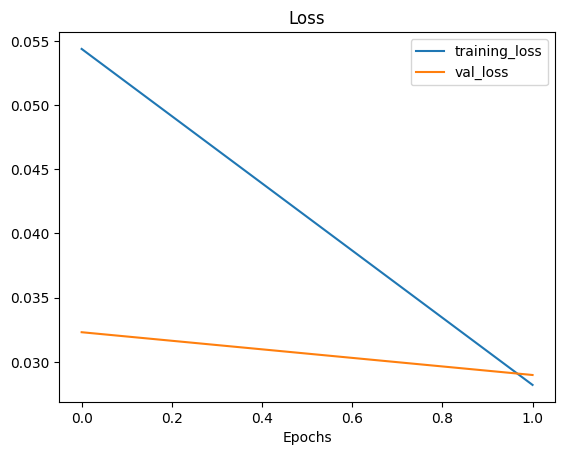

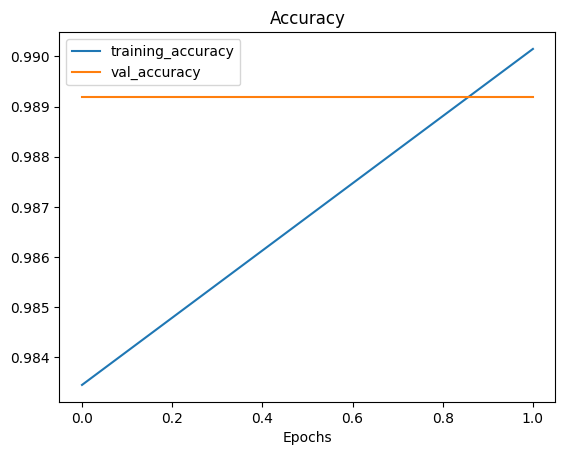

In [7]:
# Plot loss
plot_loss_curves(history=history_renet50)

In [8]:
model_renet50.evaluate(test_data)

79/79 ━━━━━━━━━━━━━━━━━━━━ 144s 2s/step - accuracy: 0.9864 - loss: 0.0333


[0.033302921801805496, 0.9864000082015991]

## Fine-tune model

In [9]:
# Data Augmentation
data_augmentation = keras.Sequential([
    layers.Input(shape=(224,224,3)),
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomHeight(0.2),
    layers.RandomWidth(0.2),
],name="data_augmentation")



In [10]:
# 1. Create base model
base_model = tf.keras.applications.resnet.ResNet50(include_top=False)
base_model.trainable = False

# 2. Input layer
inputs = tf.keras.Input(shape=(224,224,3),name="input_layer")

# 3. Add data-augmentation
x = data_augmentation(inputs)

# 4. Preprocess the input 
x = tf.keras.applications.resnet.preprocess_input(x)

# 5. Pass inputs to base model
x = base_model(x)

# 6. Add pooling layer
x = tf.keras.layers.GlobalAveragePooling2D(name="Pooling_Layer")(x)

# 7. Create output layer
x = layers.Dropout(0.1)(x)
outputs = tf.keras.layers.Dense(2,activation="softmax",name="output_layer")(x)

# 8. create our model
model_renet50 = tf.keras.Model(inputs,outputs)

# 9. Compile the model
model_renet50.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                      optimizer=tf.keras.optimizers.Adam(),
                      metrics=["accuracy"])


In [11]:
model_renet50.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, None,      │          0 │ input_layer[0][0] │
│ (Sequential)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_3          │ (None, None,      │          0 │ data_augmentatio… │
│ (GetItem)           │ None)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_4          │ (None, None,      │          0 │ data_augmentatio… │
│ (GetItem)           │ None)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_5          │ (None, None,      │          0 │ data_augmentatio… │
│ (GetItem)           │ None)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_1 (Stack)     │ (None, None,      │          0 │ get_item_3[0][0], │
│                     │ None, 3)          │            │ get_item_4[0][0], │
│                     │                   │            │ get_item_5[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, None,      │          0 │ stack_1[0][0]     │
│                     │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, None,      │ 23,587,712 │ add_1[0][0]       │
│ (Functional)        │ None, 2048)       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Pooling_Layer       │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 2048)      │          0 │ Pooling_Layer[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_layer        │ (None, 2)         │      4,098 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,591,810 (90.00 MB)

 Trainable params: 4,098 (16.01 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [12]:
model_renet50_base_model = model_renet50.layers[2]
model_renet50_base_model.name

'resnet50'

In [13]:
# How many actual layers are trainable in our base model resnet50?
print(len(model_renet50_base_model.trainable_variables))

0


In [14]:
# Make layers trainable
model_renet50_base_model.trainable = True

# Unfreeze last 10 layers, and keep everything layers freezed
for layer in model_renet50_base_model.layers[:-10]:
    layer.trainable = False

# Recompile the whole model --> We need to recompile our model even after slight changes
model_renet50.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

In [15]:
# Now, recheck how many layers are trainable
print(len(model_renet50.trainable_variables))

14


In [16]:
history_resnet50_fine_tuned = model_renet50.fit(train_data,epochs=2,validation_data=val_data,callbacks=[create_tensorboard_callback("Final_Project_SaveModels","ResNet_Fine_Tuned")])

Saving TensorBoard log files to: Final_Project_SaveModels/ResNet_Fine_Tuned/20251216-141856
Epoch 1/2
625/625 ━━━━━━━━━━━━━━━━━━━━ 1632s 3s/step - accuracy: 0.9594 - loss: 0.1018 - val_accuracy: 0.9876 - val_loss: 0.0307
Epoch 2/2
102/625 ━━━━━━━━━━━━━━━━━━━━ 21:01 2s/step - accuracy: 0.9718 - loss: 0.0749

KeyboardInterrupt: 

In [19]:
model_renet50.evaluate(test_data)

79/79 ━━━━━━━━━━━━━━━━━━━━ 130s 2s/step - accuracy: 0.9892 - loss: 0.0319


[0.031933728605508804, 0.9891999959945679]

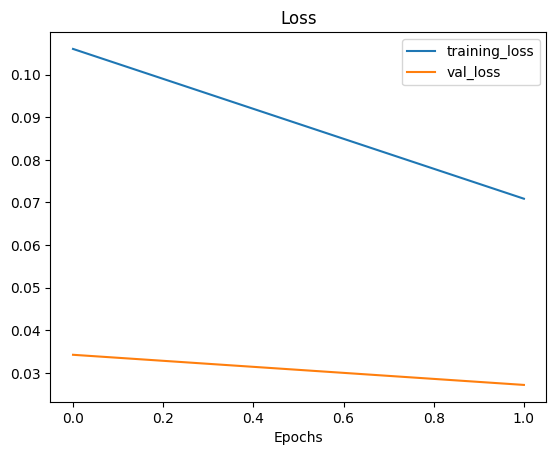

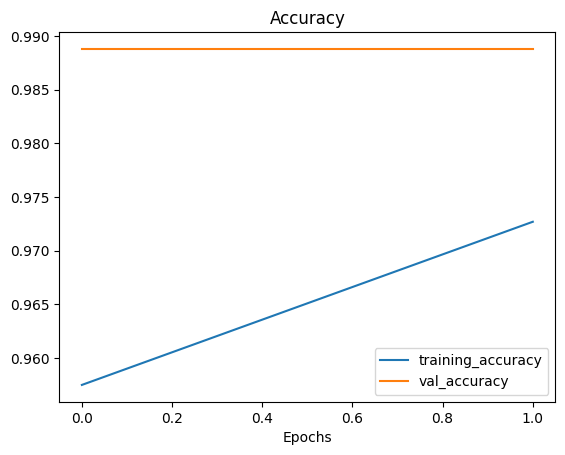

In [20]:
plot_loss_curves(history=history_resnet50_fine_tuned)

Fine-Tuned model performed better

## Now, predict images randomly


In [21]:
res_preprocess = tf.keras.applications.resnet.preprocess_input

def predict_and_show(
    model,
    image_path,
    class_names,
    img_size=(224, 224),
    preprocess=res_preprocess
):
    # Load image
    img = tf.keras.utils.load_img(image_path, target_size=img_size)
    img_array = tf.keras.utils.img_to_array(img)

    # Prepare for model
    img_batch = np.expand_dims(img_array, axis=0)
    img_batch = preprocess(img_batch)

    # Predict
    preds = model.predict(img_batch, verbose=0)
    pred_index = np.argmax(preds[0])
    confidence = preds[0][pred_index] * 100
    pred_class = class_names[pred_index]

    # Plot
    plt.figure()
    plt.imshow(img_array.astype("uint8"))
    plt.axis("off")
    plt.title(
        f"Prediction: {pred_class}\nConfidence: {confidence:.2f}%",
        fontsize=12
    )
    plt.show()

    return pred_class, confidence

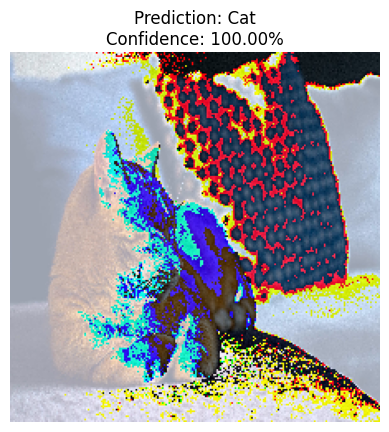

('Cat', np.float32(99.99712))

In [28]:
predict_and_show(model=model_renet50,image_path="D:\AI Bot Development\Phase 3 DeepLearning(in deep)\Tensorflow\cat-3059075.jpg",class_names=class_names,preprocess=res_preprocess)

## Save the model

In [29]:
model_renet50.save("cat_dog_classifier.h5")